<a href="https://colab.research.google.com/github/SuhaniGupta99/Crop_yield_prediction/blob/main/Crop_yield_tuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Imports & Setup
import pandas as pd
import numpy as np
from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [ ]:
#@title Upload + Load Dataset
from google.colab import files
uploaded = files.upload()
data = pd.read_csv("Crop_production.csv.zip", na_values="=")

Saving Crop_production.csv.zip to Crop_production.csv.zip


In [ ]:
#@title Remove data leakage columns
leakage_cols = ['Production_in_tons', 'Area_in_hectares']
data = data.drop(columns=leakage_cols, errors='ignore')
print("✅ Removed potential leakage columns:", leakage_cols)

✅ Removed potential leakage columns: ['Production_in_tons', 'Area_in_hectares']


In [ ]:
#@title Feature Engineering (for `data` variable)
import numpy as np

def add_engineered_features(data_in):
    data = data_in.copy()

    # Ensure all required columns exist
    for col in ["N", "P", "K", "pH", "rainfall", "temperature"]:
        if col not in data.columns:
            data[col] = np.nan

    # New engineered features
    data["NPK_mean"] = (data["N"] + data["P"] + data["K"]) / 3
    data["N_P_ratio"] = data["N"] / (data["P"] + 1e-6)
    data["rain_temp_interaction"] = data["rainfall"] * data["temperature"]
    data["rainfall_per_degree"] = data["rainfall"] / (data["temperature"] + 1e-6)

    return data

# Apply the feature engineering function
data = add_engineered_features(data)

print("✅ Feature engineering complete. New columns added:")
print(["NPK_mean", "N_P_ratio", "rain_temp_interaction", "rainfall_per_degree"])

✅ Feature engineering complete. New columns added:
['NPK_mean', 'N_P_ratio', 'rain_temp_interaction', 'rainfall_per_degree']


In [ ]:
#@title Remove Outliers (IQR Method)

def remove_outliers_iqr(df_in, factor=1.5):
    """
    Removes outliers from all numeric columns using the IQR method.
    factor=1.5 means points outside 1.5*IQR are removed.
    """
    df = df_in.copy()
    numeric_cols = df.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        before = len(df)
        df = df[(df[col] >= lower) & (df[col] <= upper)]
        after = len(df)
        removed = before - after
        if removed > 0:
            print(f"⚠️ Removed {removed} outliers from '{col}'")

    print(f"✅ Final dataset shape after outlier removal: {df.shape}")
    return df

data = remove_outliers_iqr(data, factor=1.5)


⚠️ Removed 5441 outliers from 'N'
⚠️ Removed 42875 outliers from 'P'
⚠️ Removed 1438 outliers from 'K'
⚠️ Removed 4306 outliers from 'pH'
⚠️ Removed 428 outliers from 'rainfall'
⚠️ Removed 643 outliers from 'temperature'
⚠️ Removed 1814 outliers from 'Yield_ton_per_hec'
⚠️ Removed 153 outliers from 'rainfall_per_degree'
✅ Final dataset shape after outlier removal: (42751, 15)


In [ ]:
#@title Log Transform the Target Variable

import numpy as np

# Apply log1p transform (handles zeros safely)
y = np.log1p(data["Yield_ton_per_hec"])

# Define features (make sure target column not in X)
X = data.drop(columns=["Yield_ton_per_hec"])

print("✅ Applied log transform to target variable (Yield_ton_per_hec).")


✅ Applied log transform to target variable (Yield_ton_per_hec).


In [ ]:
#@title Define features and target
X = data.drop(columns=['Yield_ton_per_hec'])
y = data['Yield_ton_per_hec']

In [31]:
#@title Safe Label Encoding

from sklearn.preprocessing import LabelEncoder

def label_encode_train_test(X_train, X_test):
    """
    Fits label encoders on training data only,
    and applies same mappings to test data.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()
    label_encoders = {}

    for col in X_train.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
        label_encoders[col] = le

    print("✅ Label encoding applied safely on:", list(label_encoders.keys()))
    return X_train, X_test, label_encoders


In [32]:
#@title Safe & Robust Stratified Split
from sklearn.model_selection import train_test_split

stratify_col = "Crop"

# 1️. Ensure no missing values in the stratification column
data[stratify_col] = data[stratify_col].fillna("Unknown")

# 2️. Group rare categories into 'Other' (with >= 2 samples)
min_samples = 2
data["Crop_grouped"] = data[stratify_col].where(
    data[stratify_col].map(data[stratify_col].value_counts()) >= min_samples, "Other"
)

# 3️. Double-check that stratification is valid
if data["Crop_grouped"].value_counts().min() < 2:
    print("Some categories still too small for stratification. Using random split instead.")
    stratify_param = None
else:
    stratify_param = data["Crop_grouped"]

# 4️. Perform the split safely
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)

print("✅ Safe stratified split complete (auto-handles rare crops).")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 5️. Encode categorical columns AFTER split
X_train, X_test, label_encoders = label_encode_train_test(X_train, X_test)
print("✅ Categorical encoding applied safely.")


✅ Safe stratified split complete (auto-handles rare crops).
Train size: 34200, Test size: 8551
✅ Label encoding applied safely on: ['State_Name', 'Crop_Type', 'Crop']
✅ Categorical encoding applied safely.


In [37]:
#@title Decision Tree Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

start_time = time.time()

dt = DecisionTreeRegressor(random_state=RANDOM_STATE)

dt_param_dist = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt', 'log2']
}

dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

print("Starting Decision Tree tuning...")
dt_random.fit(X_train, y_train)
print("Done!")

dt_best = dt_random.best_estimator_
print("\n Best Decision Tree Parameters Found:")
print(dt_random.best_params_)

y_pred_dt = dt_best.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print("\n Decision Tree (Tuned) Evaluation Results:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

end_time = time.time()
print(f"\n Total tuning time: {(end_time - start_time)/60:.2f} minutes")

dt_results = {"MAE": mae, "RMSE": rmse, "R2": r2}


Starting Decision Tree tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done!

 Best Decision Tree Parameters Found:
{'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 10, 'criterion': 'friedman_mse'}

 Decision Tree (Tuned) Evaluation Results:
MAE  : 0.3402
RMSE : 0.4849
R²   : 0.7102

 Total tuning time: 4.11 minutes


In [38]:
#@title Random Forest Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, time

start_time = time.time()

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

rf_param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

print(" Starting Random Forest tuning...")
rf_search.fit(X_train, y_train)
print("Done!")

rf_best = rf_search.best_estimator_
print("\n Best Random Forest Parameters Found:")
print(rf_search.best_params_)

y_pred_rf = rf_best.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("\n Random Forest (Tuned) Evaluation Results:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print(f"\n Total tuning time: {(time.time() - start_time)/60:.2f} minutes")

rf_results = {"MAE": mae, "RMSE": rmse, "R2": r2}


 Starting Random Forest tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done!

 Best Random Forest Parameters Found:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': True}

 Random Forest (Tuned) Evaluation Results:
MAE  : 0.3217
RMSE : 0.4687
R²   : 0.7293

 Total tuning time: 7.99 minutes


In [39]:
#@title Gradient Boosting Hyperparameter Tuning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, time

start_time = time.time()

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)

gb_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': [None, 'sqrt', 'log2']
}

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

print(" Starting Gradient Boosting tuning...")
gb_search.fit(X_train, y_train)
print("Done!")

gb_best = gb_search.best_estimator_
print("\n Best Gradient Boosting Parameters Found:")
print(gb_search.best_params_)

y_pred_gb = gb_best.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("\n Gradient Boosting (Tuned) Evaluation Results:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print(f"\n Total tuning time: {(time.time() - start_time)/60:.2f} minutes")

gb_results = {"MAE": mae, "RMSE": rmse, "R2": r2}

 Starting Gradient Boosting tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done!

 Best Gradient Boosting Parameters Found:
{'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 7, 'learning_rate': 0.05}

 Gradient Boosting (Tuned) Evaluation Results:
MAE  : 0.3233
RMSE : 0.4623
R²   : 0.7367

 Total tuning time: 3.75 minutes


In [41]:
#@title Step 11 — Save Tuned Models and Preprocessing Objects
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

joblib.dump(dt_best, "saved_models/decision_tree_best.pkl")
joblib.dump(rf_best, "saved_models/random_forest_best.pkl")
joblib.dump(gb_best, "saved_models/gradient_boosting_best.pkl")

joblib.dump(label_encoders, "saved_models/label_encoders.pkl")

joblib.dump((X_train, X_test, y_train, y_test), "saved_models/train_test_data.pkl")
print("All models and preprocessing objects saved successfully!")
print("Files saved in the 'saved_models/' folder:")
for file in os.listdir("saved_models"):
  print(" └──", file)

All models and preprocessing objects saved successfully!
Files saved in the 'saved_models/' folder:
 └── random_forest_best.pkl
 └── train_test_data.pkl
 └── gradient_boosting_best.pkl
 └── decision_tree_best.pkl
 └── label_encoders.pkl


In [42]:
#@title Model Performance Comparison
results = [
    {"Model": "Decision Tree (Tuned)", **dt_results},
    {"Model": "Random Forest (Tuned)", **rf_results},
    {"Model": "Gradient Boosting (Tuned)", **gb_results}
]
results_df = pd.DataFrame(results)
print("Tuned Model Comparison:")
display(results_df.sort_values(by="MAE"))

Tuned Model Comparison:


,Model,MAE,RMSE,R2
1,Random Forest (Tuned),0.321698,0.468650,0.729350
2,Gradient Boosting (Tuned),0.323253,0.462262,0.736678
0,Decision Tree (Tuned),0.340193,0.484917,0.710234


In [43]:
#@title Evaluate and Compare Tuned Models

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to evaluate a model
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2_Score": r2}

# Evaluate all tuned models
results = [
    evaluate_model(dt_best, X_test, y_test, "Decision Tree (Tuned)"),
    evaluate_model(rf_best, X_test, y_test, "Random Forest (Tuned)"),
    evaluate_model(gb_best, X_test, y_test, "Gradient Boosting (Tuned)")
]

# Create DataFrame
results_df = pd.DataFrame(results)

# Compute Relative MAE (%)
mean_yield = np.expm1(y_test).mean() if 'y' in locals() and np.any(y_test < 0) else y_test.mean()
results_df["Relative_MAE (%)"] = (results_df["MAE"] / mean_yield) * 100

# Sort by MAE
results_df = results_df.sort_values(by="MAE")

# Display results
print(" Tuned Model Performance Comparison:")
print(results_df[["Model", "MAE", "Relative_MAE (%)", "RMSE", "R2_Score"]].to_string(index=False))

# Interpret performance
print("\n Performance Interpretation:")
for _, row in results_df.iterrows():
    rel_mae = row["Relative_MAE (%)"]
    if rel_mae <= 10:
        comment = "🔥 Excellent"
    elif rel_mae <= 15:
        comment = "✅ Good"
    elif rel_mae <= 25:
        comment = "⚖️ Acceptable"
    else:
        comment = "⚠️ Needs Improvement"
    print(f"{row['Model']}: {rel_mae:.2f}% → {comment}")


 Tuned Model Performance Comparison:
                    Model      MAE  Relative_MAE (%)     RMSE  R2_Score
    Random Forest (Tuned) 0.321698         23.396619 0.468650  0.729350
Gradient Boosting (Tuned) 0.323253         23.509708 0.462262  0.736678
    Decision Tree (Tuned) 0.340193         24.741721 0.484917  0.710234

 Performance Interpretation:
Random Forest (Tuned): 23.40% → ⚖️ Acceptable
Gradient Boosting (Tuned): 23.51% → ⚖️ Acceptable
Decision Tree (Tuned): 24.74% → ⚖️ Acceptable



📌 Generating plots for: Decision Tree (Tuned)


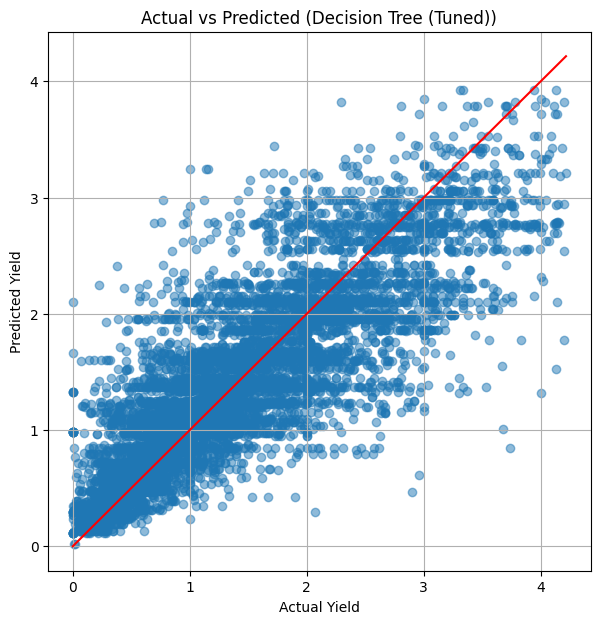

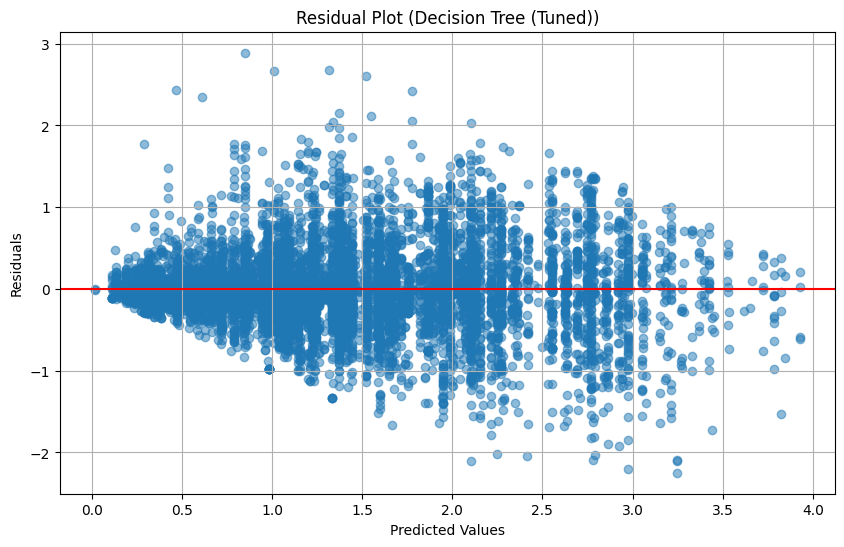

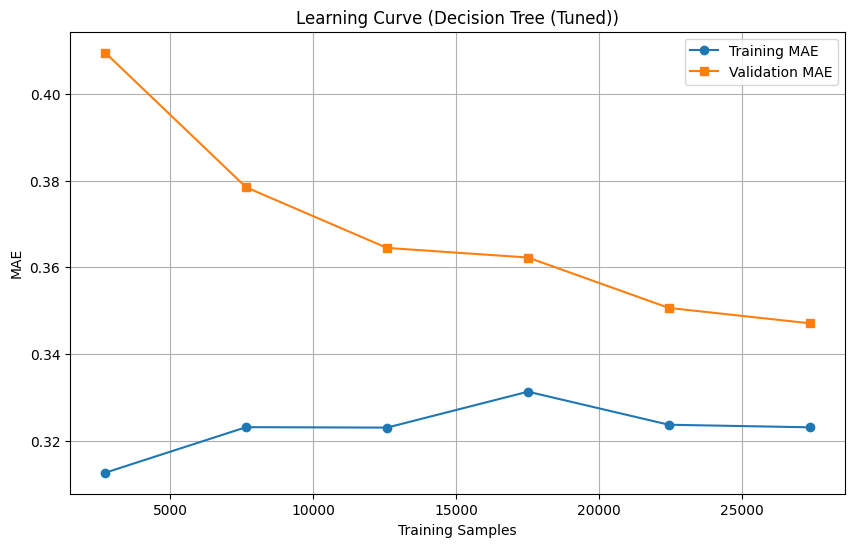


📌 Generating plots for: Random Forest (Tuned)


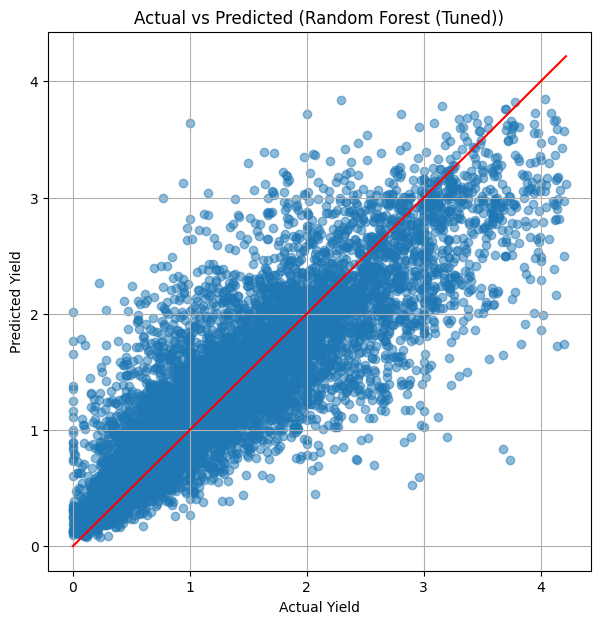

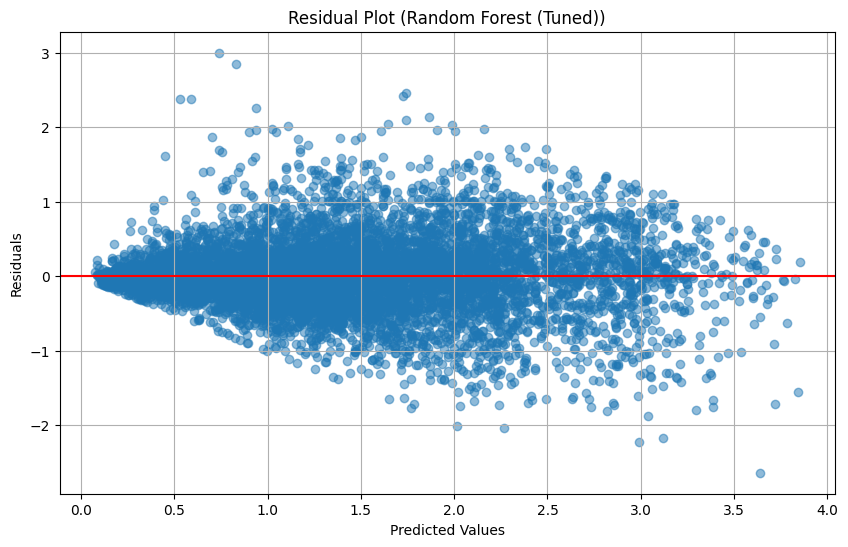

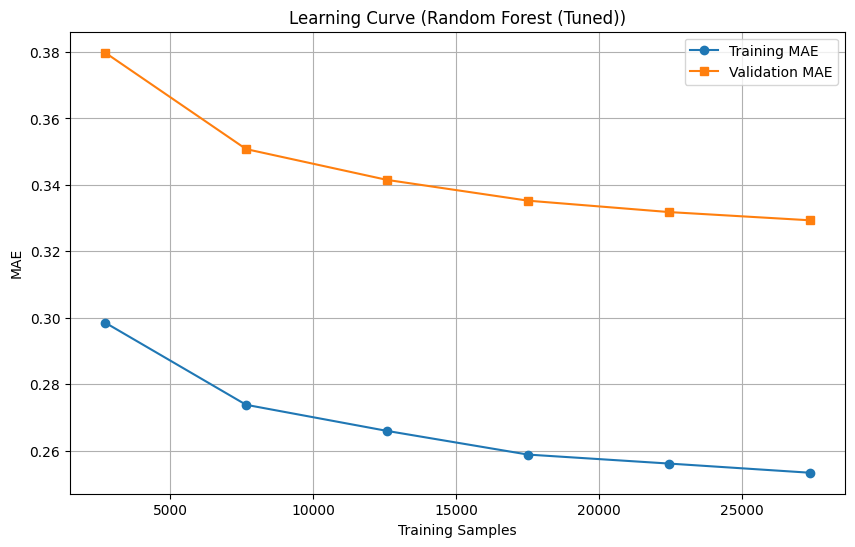


📌 Generating plots for: Gradient Boosting (Tuned)


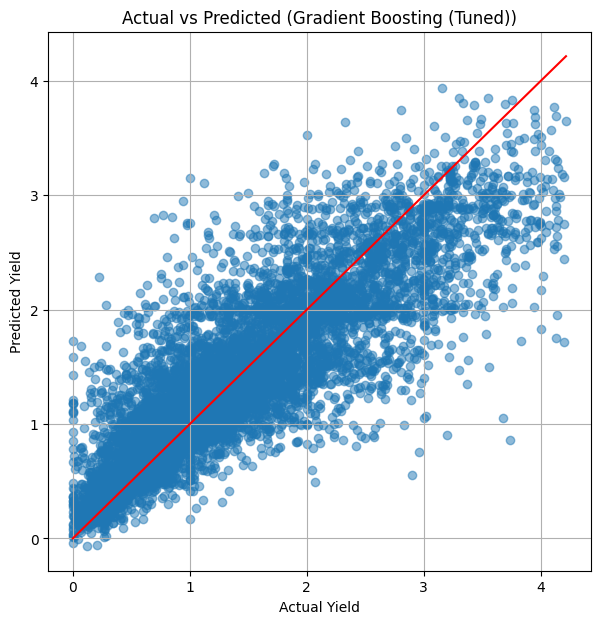

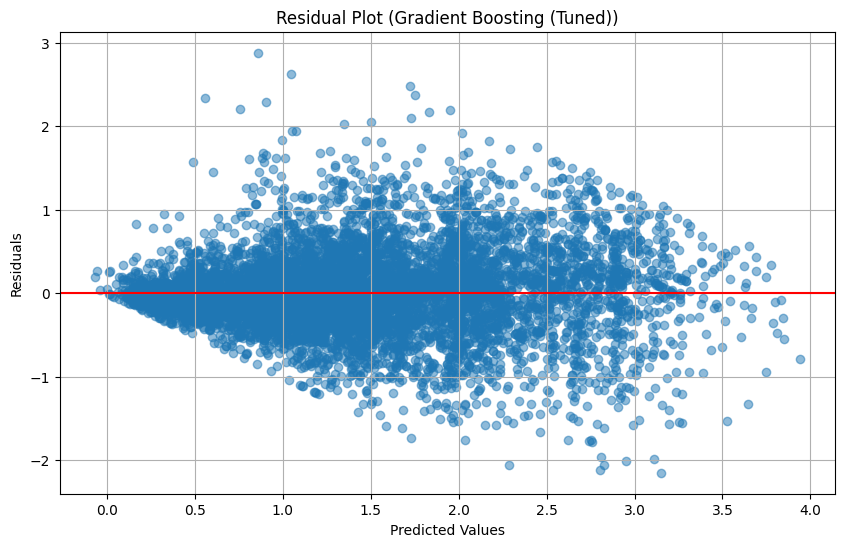

KeyboardInterrupt: 

In [44]:
# PLOTS FOR ALL TUNED MODELS
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
tuned_models = {
    "Decision Tree (Tuned)": dt_best,
    "Random Forest (Tuned)": rf_best,
    "Gradient Boosting (Tuned)": gb_best
}

for name, model in tuned_models.items():
    print(f"\n====================================")
    print(f"📌 Generating plots for: {name}")
    print(f"====================================")

    # Ensure model is fitted
    model.fit(X_train, y_train)

    # Predictions
    preds = model.predict(X_test)

    # 1️. ACTUAL vs PREDICTED
    plt.figure(figsize=(7,7))
    plt.scatter(y_test, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r')
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(f"Actual vs Predicted ({name})")
    plt.grid(True)
    plt.show()

    # 2️. RESIDUAL PLOT
    residuals = y_test - preds

    plt.figure(figsize=(10,6))
    plt.scatter(preds, residuals, alpha=0.5)
    plt.axhline(0, color='red')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({name})")
    plt.grid(True)
    plt.show()


    # 3️. LEARNING CURVE
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_train, y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1,
        random_state=42
    )

    train_mean = -train_scores.mean(axis=1)
    test_mean = -test_scores.mean(axis=1)

    plt.figure(figsize=(10,6))
    plt.plot(train_sizes, train_mean, marker='o', label="Training MAE")
    plt.plot(train_sizes, test_mean, marker='s', label="Validation MAE")
    plt.xlabel("Training Samples")
    plt.ylabel("MAE")
    plt.title(f"Learning Curve ({name})")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
from google.colab import files
uploaded_files = files.upload()

In [1]:
import joblib

dt_best = joblib.load("decision_tree_best.pkl")
rf_best = joblib.load("random_forest_best.pkl")
gb_best = joblib.load("gradient_boosting_best.pkl")

print("All models and preprocessing objects loaded successfully!")


FileNotFoundError: [Errno 2] No such file or directory: 'decision_tree_best.pkl'